# Robust Optimization

The core idea: stop treating your estimate $\hat\mu$ as truth. Admit the true $\mu$ lives *somewhere* in an **uncertainty set** $\mathcal{U}$ around your estimate, and optimize against the **worst case** the set allows.

Standard mean-variance maximizes $\mu^Tw$. Robust mean-variance maximizes the *worst-case* return over the uncertainty set:

$$
\max_w \ \min_{\mu \in \mathcal{U}} \ \mu^Tw \quad \text{s.t.} \quad w^T\Sigma w \le \sigma_{\max}^2, \ \ \mathbf{1}^Tw = 1
$$

Read the inner and outer pieces:

- **Inner** $\min_{\mu \in \mathcal{U}} \mu^Tw$ — "nature" picks the *worst* expected-return vector in the set, given your weights. Adversarial.
- **Outer** $\max_w$ — you pick weights anticipating that worst case.

This is a **min-max** (or "adversarial") problem. You're not optimizing for your best guess; you're optimizing for the worst thing that could happen within your uncertainty about $\mu$. The payoff is robustness: a portfolio that doesn't blow up if your return estimates were off, which is exactly the Markowitz failure mode.

In [1]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

**The uncertainty set is the modeling choice.** Two standard shapes:

- **Box** $\mathcal{U} = \{\mu : |\mu_i - \hat\mu_i| \le \delta_i\}$ — each return within $\pm\delta_i$ independently. Simple; leads to a linear correction.
- **Ellipsoidal** $\mathcal{U} = \{\mu : (\mu - \hat\mu)^T\Sigma_\mu^{-1}(\mu - \hat\mu) \le \kappa^2\}$ — the truth is within $\kappa$ "standard errors" of $\hat\mu$, where $\Sigma_\mu$ is the covariance of the *estimate*. This is the statistically natural one — it's the confidence ellipsoid of the estimator — and it's the one that gives an SOCP.

That inner minimization has a closed form — the worst-case return is your estimated return *minus a penalty proportional to a norm of the position*. And that norm term $\|\Sigma_\mu^{1/2}w\|_2$ is exactly a second-order cone term. So the robust problem is an SOCP, and **the $-\kappa\|\cdots\|$ penalty automatically shrinks positions in directions where your return estimate is uncertain** — it *structurally refuses* to over-bet on noisy estimates. Robust optimization is the formal, optimization-native answer to error-maximization, and it's "free" in the sense that it stays SOCP.

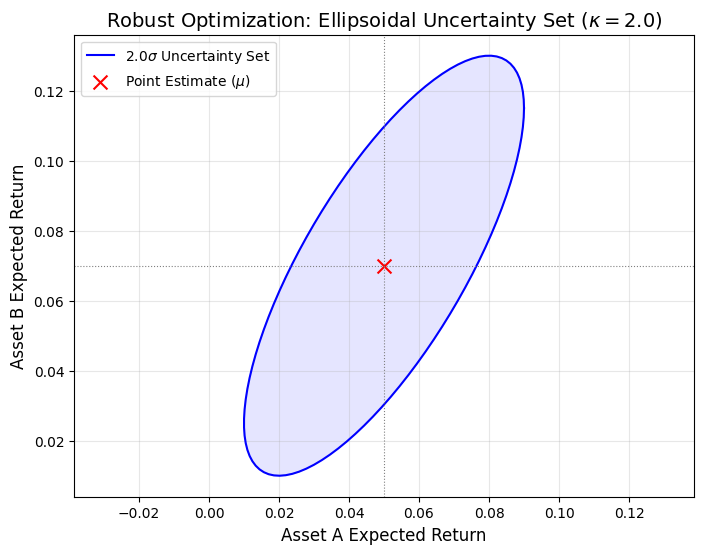

In [2]:

def plot_uncertainty_ellipsoid(mu, cov_matrix, kappa, num_points=100):
    """
    Plots the kappa-standard error uncertainty ellipsoid for two assets.
    
    Parameters:
    mu (np.array): 1D array of expected returns [mu_A, mu_B]
    cov_matrix (np.array): 2x2 covariance matrix
    kappa (float): The size of the uncertainty set (number of standard errors)
    num_points (int): Resolution of the plotted line
    """
    # Ensure inputs are the correct numpy shape
    mu = np.asarray(mu)
    
    # 1. Generate a standard unit circle in 2D space
    theta = np.linspace(0, 2 * np.pi, num_points)
    unit_circle = np.array([np.cos(theta), np.sin(theta)])  # Shape: (2, num_points)
    
    # 2. Extract the Cholesky factor (L)
    # The matrix must be strictly Positive Definite here. 
    # If Ledoit-Wolf shrinkage was required, the shrunk matrix goes in here.
    L = np.linalg.cholesky(cov_matrix)
    
    # 3. Transform the circle into the uncertainty ellipsoid
    # - Multiply by L to apply the structural correlation and variances (stretching/tilting)
    # - Scale by kappa to define the boundary size
    # - Shift the center to the expected return vector (mu)
    ellipsoid = mu[:, None] + kappa * (L @ unit_circle)
    
    # --- Plotting Architecture ---
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot the boundary and the point estimate
    ax.fill(ellipsoid[0, :], ellipsoid[1, :], color='blue', alpha=0.1)
    ax.plot(ellipsoid[0, :], ellipsoid[1, :], label=rf'${kappa}\sigma$ Uncertainty Set', color='blue')
    ax.scatter(mu[0], mu[1], color='red', marker='x', s=100, label=r'Point Estimate ($\mu$)')
    
    # Formatting the chart
    ax.set_xlabel('Asset A Expected Return', fontsize=12)
    ax.set_ylabel('Asset B Expected Return', fontsize=12)
    ax.set_title(rf'Robust Optimization: Ellipsoidal Uncertainty Set ($\kappa={kappa}$)', fontsize=14)
    ax.axhline(mu[1], color='grey', linewidth=0.8, linestyle=':')
    ax.axvline(mu[0], color='grey', linewidth=0.8, linestyle=':')
    
    # Enforce equal aspect ratio so the tilt reflects true mathematical correlation
    ax.set_aspect('equal', 'datalim') 
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    
    plt.show()

# ==========================================
# Example Execution for a Masterclass Demo
# ==========================================
if __name__ == "__main__":
    # Asset A: 5% return. Asset B: 7% return.
    mu_demo = np.array([0.05, 0.07])
    
    # Asset A variance = 0.0004 (2% vol)
    # Asset B variance = 0.0009 (3% vol)
    # Covariance = 0.00045 (Correlation = 0.75)
    cov_demo = np.array([[0.0004, 0.00045],
                         [0.00045, 0.0009]])
    
    # Plot a 2-standard error uncertainty boundary
    plot_uncertainty_ellipsoid(mu_demo, cov_demo, kappa=2.0)

The key move is that the **inner minimization has a closed form**, which collapses the whole thing into a single tractable problem.

**Solve the inner problem.** Fix $w$. The adversary solves:

$$
\min_{\mu \in \mathcal{U}} \mu^Tw, \qquad \mathcal{U} = \{\mu : (\mu - \hat\mu)^T\Sigma_\mu^{-1}(\mu - \hat\mu) \le \kappa^2\}
$$

Geometrically: the adversary wants to make $\mu^Tw$ as small as possible, picking $\mu$ from inside an ellipsoid centered at $\hat\mu$. The objective $\mu^Tw$ is linear in $\mu$, so the worst point is on the *boundary* of the ellipsoid, pushed as far as possible in the $-w$ direction. That's a constrained linear minimization over an ellipsoid, which has a clean answer:

$$
\min_{\mu \in \mathcal{U}} \mu^Tw = \hat\mu^Tw - \kappa\sqrt{w^T\Sigma_\mu w}
$$

Write $\mu = \hat\mu + \Sigma_\mu^{1/2}u$ where $\|u\| \le \kappa$ (any point in the ellipsoid). Then $\mu^Tw = \hat\mu^Tw + u^T\Sigma_\mu^{1/2}w$. The adversary minimizes over $\|u\|\le\kappa$, and the most-negative value of $u^T(\Sigma_\mu^{1/2}w)$ is achieved by pointing $u$ exactly opposite to $\Sigma_\mu^{1/2}w$ with full length $\kappa$ — giving $-\kappa\|\Sigma_\mu^{1/2}w\| = -\kappa\sqrt{w^T\Sigma_\mu w}$ (Cauchy-Schwarz, equality at the aligned vector). So the worst-case return is your nominal return minus a penalty.

**Substitute back.** The min-max becomes a plain maximization in $w$:

$$
\max_w \ \hat\mu^Tw - \kappa\sqrt{w^T\Sigma_\mu w} \quad \text{s.t.} \quad w^T\Sigma w \le \sigma_{\max}^2, \ \ \mathbf{1}^Tw = 1
$$

The adversary is gone — absorbed into that $-\kappa\sqrt{w^T\Sigma_\mu w}$ penalty term. And that penalty is a **norm**: $\sqrt{w^T\Sigma_\mu w} = \|\Sigma_\mu^{1/2}w\|_2$. So the objective is "nominal return minus $\kappa$ times a norm," and the risk cap is a second-order cone constraint. The whole thing is an **SOCP**:

$$
\max_w \ \hat\mu^Tw - \kappa\|\Sigma_\mu^{1/2}w\|_2 \quad \text{s.t.} \quad \|L^Tw\|_2 \le \sigma_{\max}, \ \ \mathbf{1}^Tw = 1
$$

This is the payoff: the seemingly-hard adversarial problem is just an ordinary SOCP that any cone solver handles.

In [3]:
def optimize_robust_portfolio(mu_hat, Sigma, kappa, sigma_max, long_only=True):
    """
    Solves the collapsed SOCP form of the Max-Min Robust Portfolio Optimization.
    
    Parameters:
    mu_hat (np.array): 1D array of point-estimate expected returns.
    Sigma (np.array): 2D Positive Definite covariance matrix.
    kappa (float): The uncertainty radius (number of standard errors).
    sigma_max (float): Maximum allowable portfolio volatility.
    long_only (bool): If True, enforces w >= 0.
    
    Returns:
    dict: Optimal weights, the worst-case return, and the solver status.
    """
    n = len(mu_hat)
    
    # 1. Cholesky Decomposition for the SOC constraints
    # Sigma = L @ L.T, therefore w^T Sigma w = ||L^T w||_2^2
    # Note: Sigma must be strictly Positive Definite (e.g., via Ledoit-Wolf shrinkage)
    L = np.linalg.cholesky(Sigma)
    
    # 2. Define the optimization variable
    w = cp.Variable(n)
    
    # 3. Formulate the collapsed objective
    # expected_return = mu_hat.T @ w
    # risk_penalty = kappa * cp.norm(L.T @ w, 2)
    worst_case_return = (mu_hat.T @ w) - (kappa * cp.norm(L.T @ w, 2))
    objective = cp.Maximize(worst_case_return)
    
    # 4. Formulate the Second-Order Cone constraints
    constraints = [
        cp.sum(w) == 1,                                  # Fully invested
        cp.norm(L.T @ w, 2) <= sigma_max                 # Volatility constraint
    ]
    
    if long_only:
        constraints.append(w >= 0)
        
    # 5. Solve the SOCP
    prob = cp.Problem(objective, constraints)
    
    # CVXPY will automatically route this to an SOCP solver (like CLARABEL or ECOS)
    prob.solve()
    
    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise ValueError(f"Optimization failed. Solver status: {prob.status}")
        
    return {
        "weights": w.value,
        "worst_case_return": prob.value,
        "portfolio_volatility": np.linalg.norm(L.T @ w.value, 2)
    }

# ==========================================
# Example Execution 
# ==========================================
if __name__ == "__main__":
    # 3 Assets: Point estimates for expected returns
    mu_est = np.array([0.0720, 0.1552, 0.1754, 0.0898, 0.4290, 0.3929, 0.3217, 0.1838])
    
    # Positive Definite Covariance Matrix
    cov_matrix = np.array([
        [0.0946, 0.0374, 0.0349, 0.0348, 0.0542, 0.0368, 0.0321, 0.0327],
        [0.0374, 0.0775, 0.0387, 0.0367, 0.0382, 0.0363, 0.0356, 0.0342],
        [0.0349, 0.0387, 0.0624, 0.0336, 0.0395, 0.0369, 0.0338, 0.0243],
        [0.0348, 0.0367, 0.0336, 0.0682, 0.0402, 0.0335, 0.0436, 0.0371],
        [0.0542, 0.0382, 0.0395, 0.0402, 0.1724, 0.0789, 0.0700, 0.0501],
        [0.0368, 0.0363, 0.0369, 0.0335, 0.0789, 0.0909, 0.0536, 0.0449],
        [0.0321, 0.0356, 0.0338, 0.0436, 0.0700, 0.0536, 0.0965, 0.0442],
        [0.0327, 0.0342, 0.0243, 0.0371, 0.0501, 0.0449, 0.0442, 0.0816]
    ])

    try:
        result = optimize_robust_portfolio(
            mu_hat=mu_est,
            Sigma=cov_matrix,
            kappa=2,             # 2 standard errors of paranoia
            sigma_max=0.3,        # Max 30% portfolio volatility
            long_only=True
        )
        
        print(f"Optimal Weights: {np.round(result['weights'], 4)}")
        print(f"Worst-Case Return: {result['worst_case_return'] * 100:.2f}%")
        print(f"Portfolio Volatility: {result['portfolio_volatility'] * 100:.2f}%")
        
    except ValueError as e:
        print(e)

Optimal Weights: [0.     0.0461 0.1971 0.     0.0573 0.4446 0.2141 0.0408]
Worst-Case Return: -16.47%
Portfolio Volatility: 24.10%


**Reading the penalty — why it fixes error-maximization.** The term $-\kappa\|\Sigma_\mu^{1/2}w\|_2$ penalizes positions in directions where your return estimate is *uncertain* (large $\Sigma_\mu$). Recall the Markowitz disease: the optimizer piles into assets with extreme estimated returns, which are the noisiest estimates. The robust penalty does the opposite — it *shrinks* the position wherever the estimate is unreliable, structurally refusing to bet big on noisy inputs. The parameter $\kappa$ tunes the paranoia: $\kappa = 0$ recovers plain Markowitz (trust the estimate fully), large $\kappa$ pulls toward the minimum-variance portfolio (trust nothing, ignore $\hat\mu$ entirely).

The connection that makes it click. Look at the penalty if $\Sigma_\mu = \tau\Sigma$ (estimate uncertainty proportional to return covariance, the no-views case): the objective becomes $\hat\mu^Tw - \kappa\sqrt{\tau}\|\Sigma^{1/2}w\|_2 = \hat\mu^Tw - \kappa\sqrt{\tau}\,\sigma_p$. That's return minus a multiple of volatility — which is structurally the mean-variance objective with the risk penalty on $\sigma_p$ instead of $\sigma_p^2$. So robust optimization with ellipsoidal $\mu$-uncertainty is almost a re-derivation of mean-variance, but penalizing standard deviation rather than variance, with the penalty strength set by how uncertain your return estimate is rather than by an arbitrary risk-aversion $\gamma$. **Robustness and risk-aversion turn out to be two views of the same penalty.**

**Where SOCP stops — SDP territory.** You're forced up to semidefinite programming when the uncertainty or the constraint is *matrix-valued*:
- **Uncertain covariance matrix** — if $\Sigma$ *itself* is uncertain (you optimize worst-case variance over a *set* of covariance matrices, not just uncertain $\mu$), the robust counterpart typically becomes an SDP. Uncertainty in a vector ($\mu$) → SOCP; uncertainty in a matrix ($\Sigma$) → SDP.
- **Nearest correlation/covariance matrix** — "find the closest valid (PSD) matrix to my broken estimate" is a projection onto the PSD cone, an SDP.